In [1]:
import math
import numpy as np
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [2]:
class Rectangle:
    def __init__(self, x, y, w, h):
        self.x = x
        self.y = y
        self.w = w
        self.h = h

class Circle:
    def __init__(self, x, y, r):
        self.x = x
        self.y = y
        self.r = r

class Point:
    def __init__(self, x, y):
        self.x = x
        self.y = y

def generate_random_rectangle(reclims, rng):
    x = rng.uniform(reclims[0][0], reclims[0][1])
    y = rng.uniform(reclims[1][0], reclims[1][1])
    w = rng.uniform(reclims[2][0], reclims[2][1])
    h = rng.uniform(reclims[3][0], reclims[3][1])
    return Rectangle(x, y, w, h)

def generate_random_circle(cirlims, rng):
    x = rng.uniform(cirlims[0][0], cirlims[0][1])
    y = rng.uniform(cirlims[1][0], cirlims[1][1])
    r = rng.uniform(cirlims[2][0], cirlims[2][1])
    return Circle(x, y, r)

def generate_random_point(plims, rng):
    x = rng.uniform(plims[0][0], plims[0][1])
    y = rng.uniform(plims[1][0], plims[1][1])
    return Point(x, y)

def check_overlap(rectangle, circle):
    # Calculate the distance between the center of the circle and the center of the rectangle
    dx = abs(circle.x - rectangle.x - rectangle.w / 2)
    dy = abs(circle.y - rectangle.y - rectangle.h / 2)

    if dx > (rectangle.w / 2 + circle.r):
        return False
    if dy > (rectangle.h / 2 + circle.r):
        return False

    return True

def generate_map(reclims, cirlims, plims, seed=0):
    rng = np.random.RandomState(seed)
    while True:
        rectangle = generate_random_rectangle(reclims, rng)
        circle = generate_random_circle(cirlims, rng)
        if not check_overlap(rectangle, circle):
            break

    while True:
        point1 = generate_random_point(plims, rng)
        point2 = generate_random_point(plims, rng)

        # set waypoint inside a rectangle defined by start point and terminal point
        plims_for_wp = [[min(point1.x, point2.x), max(point1.x, point2.x)],
                        [min(point1.y, point2.y), max(point1.y, point2.y)]]

        point3 = generate_random_point(plims_for_wp, rng)
        
        if not ((point1.x >= rectangle.x and point1.x <= rectangle.x + rectangle.w and point1.y >= rectangle.y and point1.y <= rectangle.y + rectangle.h) 
                or (math.sqrt((point1.x - circle.x) ** 2 + (point1.y - circle.y) ** 2) <= circle.r)):
            if not ((point2.x >= rectangle.x and point2.x <= rectangle.x + rectangle.w and point2.y >= rectangle.y and point2.y <= rectangle.y + rectangle.h) 
                    or (math.sqrt((point2.x - circle.x) ** 2 + (point2.y - circle.y) ** 2) <= circle.r)):
                if not ((point3.x >= rectangle.x and point3.x <= rectangle.x + rectangle.w and point3.y >= rectangle.y and point3.y <= rectangle.y + rectangle.h) 
                        or (math.sqrt((point3.x - circle.x) ** 2 + (point3.y - circle.y) ** 2) <= circle.r)):
                    break

    return [rectangle, circle, point1, point2, point3]

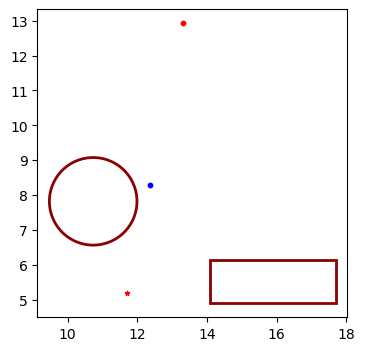

In [20]:
# generate map
reclims = [[3, 15], [3, 15], [1, 4], [1, 4]]
cirlims = [[5, 15], [5, 15], [1, 2]]
plims = [[1,20], [1, 20]]
seed = np.random.randint(0, 100)
nfz_rec, nfz_cir, start, terminal, waypoint = generate_map(reclims, cirlims, plims, seed)

# plot map
fig, ax = plt.subplots(figsize=(4, 4))

# no-fly-zone in rectangle shape
rec = patches.Rectangle((nfz_rec.x, nfz_rec.y), nfz_rec.w, nfz_rec.h, 
                        linewidth=2, edgecolor='darkred', facecolor='none')
ax.add_patch(rec)

# no-fly-zone in circle shape
cir = patches.Circle((nfz_cir.x, nfz_cir.y), nfz_cir.r, 
                     linewidth=2, edgecolor='darkred', facecolor='none')
ax.add_patch(cir)

# start point
plt.scatter(start.x, start.y, s=10, c='r', marker='*')

# terminal point
plt.scatter(terminal.x, terminal.y, s=10, c='r', marker='o')

# waypoint
plt.scatter(waypoint.x, waypoint.y, s=10, c='b')
    
ax.axis("equal")
plt.show()

In [ ]:
def generate_instance(map_size=[20, 20]):

    # generate a rectangle
    map_x, map_y = map_size[0], map_size[1]
    

    # generate a circle
    # generate a waypoint
    # generate a start point
    # generate a terminal point
    pass